# Parameter Study Analysis

This notebook imports data collected by a Daphne parameter study, analyzes
scalability and performance metrics, and visualizes results.

## 1. Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
%matplotlib inline

# Enable copy-on-write to follow pandas recommendation.
# see https://pandas.pydata.org/docs/user_guide/copy_on_write.html
pd.options.mode.copy_on_write = True

In [6]:
# Load line-delimited, gzip-compressed JSON in patches, filter rows, and 
# categorize columns to save memory.
# Replace '../output.json.gz' with the path to your JSON file.
# As a reminder, please run `go run ./daphne study` to produce this file.
chunks = pd.read_json(
    '../output.json.gz',
    compression='gzip',
    lines=True,
    convert_dates=False,
    chunksize=100000
)

def process_chunk(chunk):
    #chunk = chunk[chunk['mark'].str.startswith('Msg') | chunk['mark'].str.startswith('Study')]
    for col in ['mark', 'type', 'from', 'to']:
        chunk[col] = chunk[col].astype('category')
    return chunk

data = pd.concat((process_chunk(chunk) for chunk in chunks), ignore_index=True)

In [5]:
data2 = pd.read_parquet(
    '/home/herbert/coding/soniclabs/daphne/daphne/tracker/tryout/test.parquet'
)

data2.memory_usage(deep=True).sum()

np.int64(6300000132)

In [2]:
delayedData = dd.read_parquet(
    '/home/herbert/coding/soniclabs/daphne/daphne/tracker/tryout/test.parquet'
)

def process_chunk(chunk):
    chunk = dd.from_delayed(chunk).compute()
    chunk['mark'] = chunk['mark'].astype('category')
    return chunk

data3 = pd.concat((process_chunk(chunk) for chunk in delayedData.to_delayed()), ignore_index=True)

In [6]:
data2['mark'] = data2['mark'].astype('category')
data2.memory_usage(deep=True).sum()

np.int64(900000579)

In [8]:
data3['mark'] = data3['mark'].astype('category')
data3.memory_usage(deep=True).sum()

np.int64(900000375)

## 2. Number of Messages
The following chart illustrates the number of messages being transferred over
the network depending on the number of involved nodes and transaction rates.


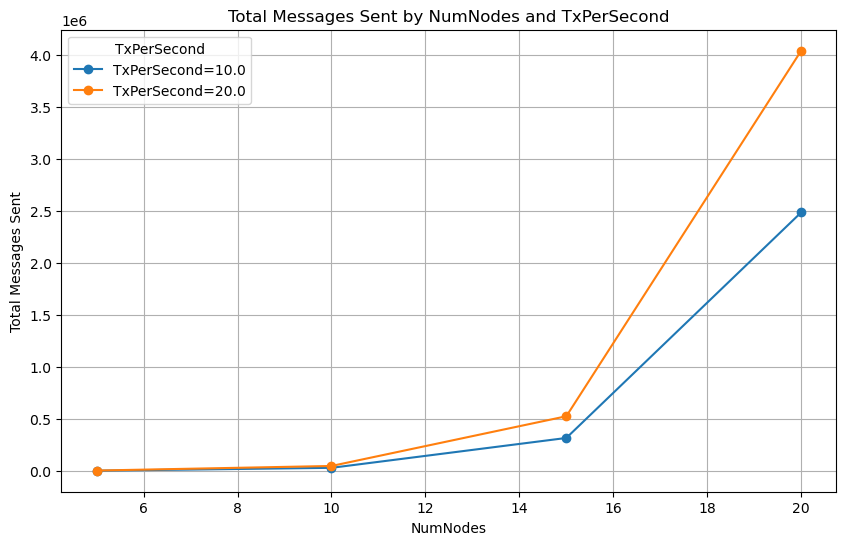

In [3]:
msgsent = data[data['mark'] == 'MsgSent']
grouped = msgsent.groupby(['sid']).size().reset_index(name='Count')

scenarios = data[data['mark'] == 'StudyStarted'][['sid', 'NumNodes', 'TxPerSecond']]

grouped = pd.merge(grouped, scenarios, on='sid')

plt.figure(figsize=(10, 6))
for tx_rate in sorted(grouped['TxPerSecond'].unique()):
    subset = grouped[grouped['TxPerSecond'] == tx_rate]
    plt.plot(subset['NumNodes'], subset['Count'], marker='o', label=f'TxPerSecond={tx_rate}')

plt.title('Total Messages Sent by NumNodes and TxPerSecond')
plt.xlabel('NumNodes')
plt.ylabel('Total Messages Sent')
plt.legend(title='TxPerSecond')
plt.grid(True)
plt.show()

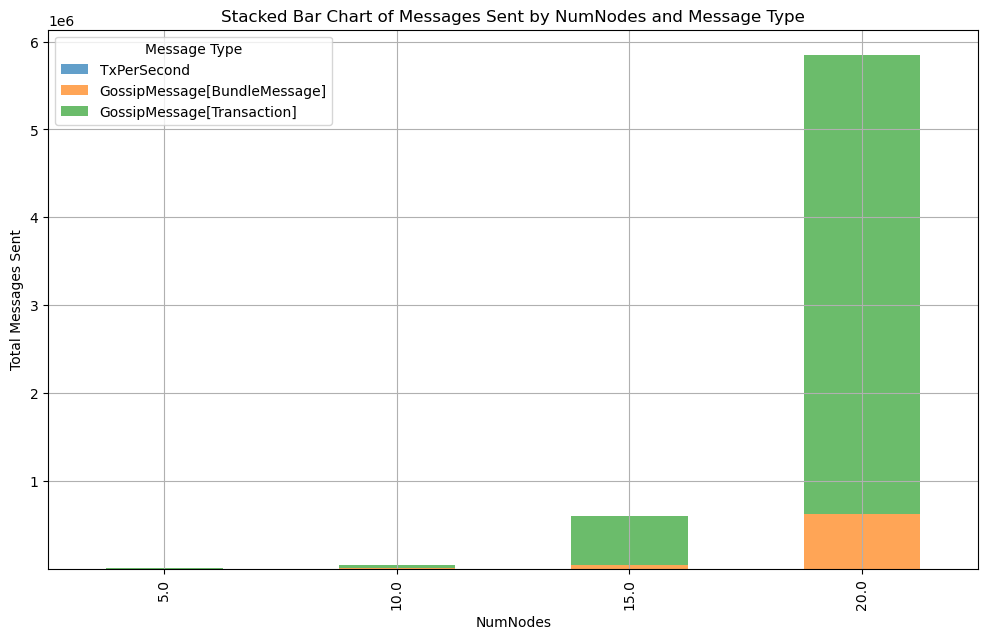

In [4]:
msgsent = data[data['mark'] == 'MsgSent']
grouped = msgsent.groupby(['sid', 'type']).size().reset_index(name='Count')

scenarios = data[data['mark'] == 'StudyStarted'][['sid', 'NumNodes', 'TxPerSecond']]
grouped = pd.merge(grouped, scenarios, on='sid')
grouped = grouped[grouped['TxPerSecond'] == 20]

pivoted = grouped.pivot_table(index=['NumNodes', 'TxPerSecond'], columns='type', values='Count', fill_value=0)
pivoted = pivoted.reset_index()

# Plot stacked bars for each TxPerSecond value
plt.figure(figsize=(12, 7))
for tx_rate in sorted(pivoted['TxPerSecond'].unique()):
    subset = pivoted[pivoted['TxPerSecond'] == tx_rate]
    subset.set_index('NumNodes').plot(kind='bar', stacked=True, ax=plt.gca(), legend=True, alpha=0.7)

plt.title('Stacked Bar Chart of Messages Sent by NumNodes and Message Type')
plt.xlabel('NumNodes')
plt.ylabel('Total Messages Sent')
plt.legend(title='Message Type')
plt.grid(True)
plt.show()